# Measurement x=15, y=0, z=0

### Imports

In [1]:

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


from ppvm_py.utils import load_object

from ppvm_py.yz_slice_utils import find_closest_coordinate_index

from ppvm_py.plotting import plot_timeseries

from ppvm_py.data_processing.yz_slice import print_yz_slice_example_from_parsed_data
from ppvm_py.data_processing.utils import create_index_to_coord_map

from ppvm_py.feature_generation.sdc import symmetric_difference_coefficient
from ppvm_py.feature_generation.pdm import pdm_approximated_velocity

### General Args

In [2]:
random_state = 4629837

# IMPORTANT: Restart Kernel when swapping datasets to reload them!
Ha = 1000

if Ha == 300:
    slice_folder_path = Path("../../../../data/4pi_re1000_ha300.360_ch28.p1/SliceYZ_x0015/")
elif Ha == 1000:
    slice_folder_path = Path("../../../../data/4pi_re1000_ha1000.384.pi/SliceYZ_x0015/")

# Estimates in determining_sigma_and_magnetic_field_strength.ipynb
sigma = -1
B_z = -1

test_size = 0.3

### Preamble

In [3]:
mses = {}  # Dict for gathering mean-squared-errors.

### Load Data

In [4]:
fld_path = slice_folder_path / Path("pkl/sliceYZ_x0015_fld.pkl")
gradF_path = slice_folder_path / Path("pkl/sliceYZ_x0015_gradF.pkl")

In [5]:
if 'fld_data' not in locals():
    fld_data = load_object(fld_path)
fld_data['index_to_coord_map'] = create_index_to_coord_map(fld_data['coord_to_index_map'])
print_yz_slice_example_from_parsed_data(fld_data)
print()

if 'gradF_data' not in locals():
    gradF_data = load_object(gradF_path)
gradF_data['index_to_coord_map'] = create_index_to_coord_map(gradF_data['coord_to_index_map'])
print_yz_slice_example_from_parsed_data(gradF_data)

Object successfully loaded from C:\Users\hydro\Documents\PhD\nuclear_fusion_cooling\data\4pi_re1000_ha1000.384.pi\SliceYZ_x0015\pkl\sliceYZ_x0015_fld.pkl
The data looks as follows:
N (number of snapshots) = 20000
n_y (grid height) = 49, n_z (grid width) = 49, n_v (number of variables) = 8
Labels:
['vx', 'vy', 'vz', 'jx', 'jy', 'jz', 'P', 'F']
Preview of the first snapshot (first 2 y, first 2 z) with coordinates:
  (y=-1.00, z=-1.00): [ 0.         0.         0.        -0.2709205  0.         0.
 -0.0004302  0.290587 ]
  (y=-1.00, z=-0.99): [ 0.000000e+00  0.000000e+00  0.000000e+00 -2.755902e-01  0.000000e+00
  4.372047e-01 -4.302696e-04  2.858409e-01]
  (y=-0.99, z=-1.00): [ 0.000000e+00  0.000000e+00  0.000000e+00 -2.637546e-01 -3.491415e+00
  0.000000e+00 -4.098474e-04  3.136015e-01]
  (y=-0.99, z=-0.99): [-3.760981e+00  4.328748e-02 -1.042420e-01 -2.076186e-01  6.084429e-03
  2.005159e-01 -4.101349e-04  3.114591e-01]

Object successfully loaded from C:\Users\hydro\Documents\PhD\nucle

### Get Existing x and y Coordinates

In [ ]:
y_coord_desired = 0
z_coord_desired = 0

# Adjust according to error message. No error will be thrown after correct adjustment.
# y_coord = y_coord_desired
# z_coord = z_coord_desired
if Ha == 300:
    y_coord = -0.01842125
    z_coord = -0.01842125
elif Ha == 1000:
    y_coord = 0
    z_coord = 0

i_y_center, i_z_center = find_closest_coordinate_index(
    fld_data['coord_to_index_map'],
    y_coord=y_coord,
    z_coord=z_coord,
)

### Define $y_{\text{true}}$

In [ ]:
y_true = fld_data['timeseries'][
    :,
    i_y_center,
    i_z_center,
    fld_data['labels'].index('vx'):fld_data['labels'].index('vx') + 1,
]
y_true_train, y_true_test = train_test_split(
    y_true,
    test_size=test_size,
    shuffle=False,
)

ss_y_true = StandardScaler()
ss_y_true.fit(y_true_train)
y_true_train = ss_y_true.transform(
    y_true_train,
    copy=False,
)
y_true_test = ss_y_true.transform(
    y_true_test,
    copy=False,
)

### General Benchmark

Assuming we know $j_y$ and the measurement distance of potentials can be infinitesimal small, we can use the partial derivative $\frac{\partial{\phi}}{\partial{y}}$ of the potential. With this, we can calculate the $v_x$ exactly using Ohm's law. The remainder is simulation error.

This error is taken as benchmark to compare all methods against.

In [8]:
part_phi_y = gradF_data['timeseries'][
    :,
    i_y_center,
    i_z_center,
    gradF_data['labels'].index('dfdy'):gradF_data['labels'].index('dfdy') + 1,
    ]
j_y_center = fld_data['timeseries'][
    :,
    i_y_center,
    i_z_center,
    fld_data['labels'].index('jy'):fld_data['labels'].index('jy') + 1,
    ]

_, part_phi_y_test, _, j_y_center_test = train_test_split(
    part_phi_y,
    j_y_center,
    test_size=test_size,
    shuffle=False,
    )
v_x_ohms_law_test = (part_phi_y_test - (j_y_center_test / sigma)) / B_z
y_pred_ohms_law_test = ss_y_true.transform(
    v_x_ohms_law_test,
    copy=False,
    )
mse_ohms_law = mean_squared_error(y_true_test, y_pred_ohms_law_test)
mses['General Benchmark'] = mse_ohms_law
print(f"mse(ohm's law) = {mse_ohms_law}")
# plot_timeseries(
#     data_list=[
#         y_true_test,
#         y_pred_ohms_law_test,
#         ],
#     )

mse(ohm's law) = 2.6041296004088333e-05


### Potential Difference Method (SDC) Benchmark
Assume we know $j_y$, but we are restricted the the potential measurements $\phi$ from our DNS.

A simple feature used in the experiments is the symmetric difference coefficient $\frac{\Delta{\phi}}{\Delta{y}}$ to approximate $\frac{\partial{\phi}}{\partial{y}}$. This is also called *Potential Difference Method*. With this and $j_y$, Ohm's law can be approximated to calculate $v_x$.

We use the smallest difference possible to calculate $\frac{\Delta{\phi}}{\Delta{y}}$. With this, we have a benchmark for methods that use the Symmetric Difference Coefficient as singular feature.

##### Define Points $y_1$ and $y_2$

y_1_y = (y_1_y, y_1_z)

y_2_y = (y_2_y, y_2_z)

y_1_y < y_coord < y_2_y

y_1_z = z_coord = y_2_z

In [9]:
# """Coordinates by using delta_l
# """

# delta_l = 0.1  # y, z domain = [-1, 1]


# # Find y_1
# y_1_y_desired = y_coord - delta_l / 2
# y_1_z_desired = z_coord

# # Adjust according to error message. No error will be thrown after correct adjustment.
# # y_1_y = y_1_y_desired
# # y_1_z = y_1_z_desired
# if Ha == 300:
#     y_1_y = -0.05560156
#     y_1_z = -0.01842125
# elif Ha == 1000:
#     y_1_y = -0.03460649
#     y_1_z = 0.0

# i_y_1_y, i_y_1_z = find_closest_coordinate_index(
#     fld_data['coord_to_index_map'],
#     y_coord=y_1_y,
#     z_coord=y_1_z,
#     )


# # Find y_2
# y_2_y_desired = y_coord + delta_l / 2
# y_2_z_desired = z_coord

# # Adjust according to error message. No error will be thrown after correct adjustment.
# # y_2_y = y_2_y_desired
# # y_2_z = y_2_z_desired
# if Ha == 300:
#     y_2_y = 0.01842125
#     y_2_z = -0.01842125
# elif Ha == 1000:
#     y_2_y = 0.03460649
#     y_2_z = 0.0

# i_y_2_y, i_y_2_z = find_closest_coordinate_index(
#     fld_data['coord_to_index_map'],
#     y_coord=y_2_y,
#     z_coord=y_2_z,
#     )

In [10]:
"""Coordinates by using delta_i
"""

delta_i = 1


i_y_1_y = i_y_center - delta_i
i_y_1_z = i_z_center

i_y_2_y = i_y_center + delta_i
i_y_2_z = i_z_center

y_1_y, y_1_z = fld_data['index_to_coord_map'][i_y_1_y, i_y_1_z]
y_2_y, y_2_z = fld_data['index_to_coord_map'][i_y_2_y, i_y_2_z]

In [11]:
"""Coordinate Checkup
"""
print(f"Center: y = {fld_data['index_to_coord_map'][i_y_center, i_z_center]}, z = {fld_data['index_to_coord_map'][i_y_center, i_z_center]}")
print()
print(f"y_1 Coordinates: y = {y_1_y}, z = {y_1_z}")
print(f"Difference to center: ", end='')
print(f"delta_y^y_1 = {y_1_y - y_coord}, delta_z^y_1 = {y_1_z - z_coord}, ", end='')
print(f"delta_i_y^y_1 = {i_y_1_y - i_y_center}, delta_i_z^y_1 = {i_y_1_z - i_z_center}")
print()
print(f"y_2 Coordinates: y = {y_2_y}, z = {y_2_z}")
print(f"Difference to center: ", end='')
print(f"delta_y^y_2 = {y_2_y - y_coord}, delta_z^y_2 = {y_2_z - z_coord}, ", end='')
print(f"delta_i_y^y_2 = {i_y_2_y - i_y_center}, delta_i_z^y_2 = {i_y_2_z - i_z_center}")
print()
delta_y = y_2_y - y_1_y
delta_z = y_2_z - y_1_z
print(f"Difference between y_1 to y_2: ", end='')
print(f"delta_y = {delta_y}, delta_z = {delta_z}, ", end='')
print(f"delta_i_y = {i_y_2_y - i_y_1_y}, delta_i_z = {i_y_2_z - i_y_1_z}")

Center: y = (0.0, 0.0), z = (0.0, 0.0)

y_1 Coordinates: y = -0.03460649, z = 0.0
Difference to center: delta_y^y_1 = -0.03460649, delta_z^y_1 = 0.0, delta_i_y^y_1 = -1, delta_i_z^y_1 = 0

y_2 Coordinates: y = 0.03460649, z = 0.0
Difference to center: delta_y^y_2 = 0.03460649, delta_z^y_2 = 0.0, delta_i_y^y_2 = 1, delta_i_z^y_2 = 0

Difference between y_1 to y_2: delta_y = 0.06921298, delta_z = 0.0, delta_i_y = 2, delta_i_z = 0


##### Prepare Data

In [12]:
phi_y_1 = fld_data['timeseries'][
    :,
    i_y_1_y,
    i_y_1_z,
    fld_data['labels'].index('F'):fld_data['labels'].index('F') + 1,
    ]
_, phi_y_1_test = train_test_split(
    phi_y_1,
    test_size=test_size,
    shuffle=False,
    )

phi_y_2 = fld_data['timeseries'][
    :,
    i_y_2_y,
    i_y_2_z,
    fld_data['labels'].index('F'):fld_data['labels'].index('F') + 1,
    ]
_, phi_y_2_test = train_test_split(
    phi_y_2,
    test_size=test_size,
    shuffle=False,
    )

##### Testing

In [13]:
approx_part_phi_y_test = symmetric_difference_coefficient(
    former_point=phi_y_1_test,
    latter_point=phi_y_2_test,
    delta_l=delta_y,
    )
v_x_sdc_test = (approx_part_phi_y_test - (j_y_center_test / sigma)) / B_z
y_pred_sdc_test = ss_y_true.transform(
    v_x_sdc_test,
    copy=False,
    )
mse_sdc = mean_squared_error(y_true_test, y_pred_sdc_test)
mses['PDM Benchmark'] = mse_sdc
print(f"mse(pdm_bench) = {mse_sdc}")
# plot_timeseries(
#     data_list=[
#         y_true_test,
#         y_pred_sdc_test,
#         ],
#     )

mse(pdm_bench) = 0.00420579468061199


### Potential Difference Method (PDM)

##### Prepare Data

In [14]:
phi_y_1 = fld_data['timeseries'][
    :,
    i_y_1_y,
    i_y_1_z,
    fld_data['labels'].index('F'):fld_data['labels'].index('F') + 1,
    ]
_, phi_y_1_test = train_test_split(
    phi_y_1,
    test_size=test_size,
    shuffle=False,
    )

phi_y_2 = fld_data['timeseries'][
    :,
    i_y_2_y,
    i_y_2_z,
    fld_data['labels'].index('F'):fld_data['labels'].index('F') + 1,
    ]
_, phi_y_2_test = train_test_split(
    phi_y_2,
    test_size=test_size,
    shuffle=False,
    )

##### Testing

mse(pdm) = 0.005341697718075174


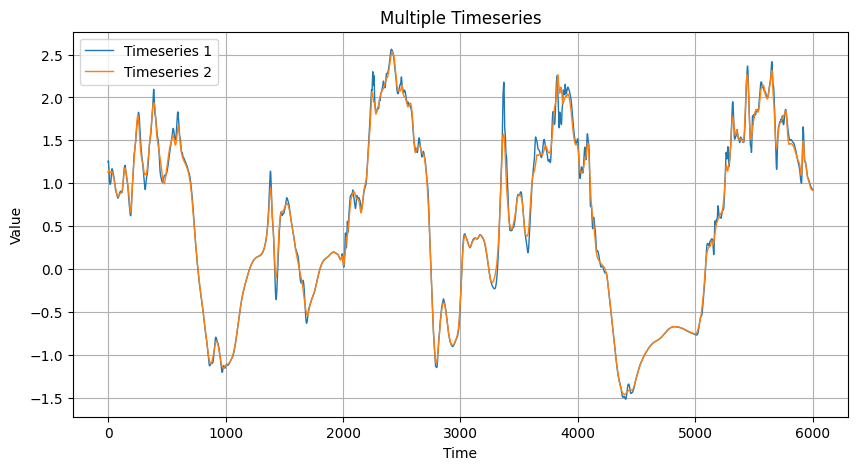

In [15]:
v_x_pdm_test = pdm_approximated_velocity(
    former_point=phi_y_1_test,
    latter_point=phi_y_2_test,
    delta_l=delta_y,
    B=B_z,
    )
y_pred_pdm_test = ss_y_true.transform(
    v_x_pdm_test,
    copy=False,
    )
mse_pdm = mean_squared_error(y_true_test, y_pred_pdm_test)
mses['PDM'] = mse_pdm
print(f"mse(pdm) = {mse_pdm}")
plot_timeseries(
    data_list=[
        y_true_test,
        y_pred_pdm_test,
        ],
    )

### Linear Scaled PDM (cPDM)

##### Prepare Data

In [16]:
phi_y_1 = fld_data['timeseries'][
    :,
    i_y_1_y,
    i_y_1_z,
    fld_data['labels'].index('F'):fld_data['labels'].index('F') + 1,
    ]
phi_y_1_train, phi_y_1_test = train_test_split(
    phi_y_1,
    test_size=test_size,
    shuffle=False,
    )

phi_y_2 = fld_data['timeseries'][
    :,
    i_y_2_y,
    i_y_2_z,
    fld_data['labels'].index('F'):fld_data['labels'].index('F') + 1,
    ]
phi_y_2_train, phi_y_2_test = train_test_split(
    phi_y_2,
    test_size=test_size,
    shuffle=False,
    )

##### Training

In [17]:
v_x_pdm_train = pdm_approximated_velocity(
    former_point=phi_y_1_train,
    latter_point=phi_y_2_train,
    delta_l=delta_y,
    B=B_z,
    )
v_x_pdm_train = ss_y_true.transform(
    v_x_pdm_train,
    copy=False,
    )

model = LinearRegression(fit_intercept=False)
model.fit(
    X = v_x_pdm_train,
    y = y_true_train,
    )
c =  1 / model.coef_[0, 0]

##### Testing

mse(c-PDM) = 0.005186293388467599


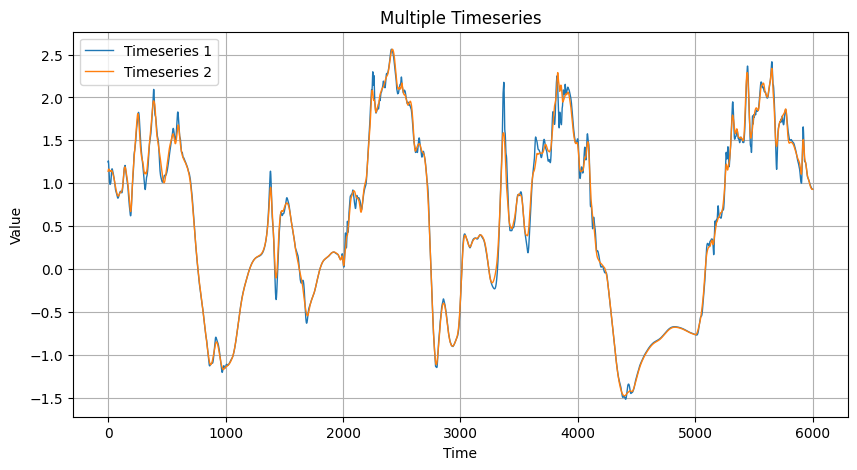

In [18]:
v_x_pdm_test = pdm_approximated_velocity(
    former_point=phi_y_1_test,
    latter_point=phi_y_2_test,
    delta_l=delta_y,
    B=B_z,
    )
v_x_pdm_test = ss_y_true.transform(
    v_x_pdm_test,
    copy=False,
    )
y_pred_c_pdm_test = v_x_pdm_test / c
mse_c_pdm = mean_squared_error(y_true_test, y_pred_c_pdm_test)
mses['c-PDM'] = mse_c_pdm
print(f"mse(c-PDM) = {mse_c_pdm}")
plot_timeseries(
    data_list=[
        y_true_test,
        y_pred_c_pdm_test,
        ],
    )

### Linear Regression on Feature: PDM

##### Prepare Data

In [19]:
phi_y_1 = fld_data['timeseries'][
    :,
    i_y_1_y,
    i_y_1_z,
    fld_data['labels'].index('F'):fld_data['labels'].index('F') + 1,
    ]
phi_y_1_train, phi_y_1_test = train_test_split(
    phi_y_1,
    test_size=test_size,
    shuffle=False,
    )

phi_y_2 = fld_data['timeseries'][
    :,
    i_y_2_y,
    i_y_2_z,
    fld_data['labels'].index('F'):fld_data['labels'].index('F') + 1,
    ]
phi_y_2_train, phi_y_2_test = train_test_split(
    phi_y_2,
    test_size=test_size,
    shuffle=False,
    )

##### Training

In [20]:
v_x_pdm_train = pdm_approximated_velocity(
    former_point=phi_y_1_train,
    latter_point=phi_y_2_train,
    delta_l=delta_y,
    B=B_z,
    )
v_x_pdm_train = ss_y_true.transform(
    v_x_pdm_train,
    copy=False,
    )

model = LinearRegression()
model.fit(
    X = v_x_pdm_train,
    y = y_true_train,
    );

##### Testing

mse(LR-PDM) = 0.005208824754777562


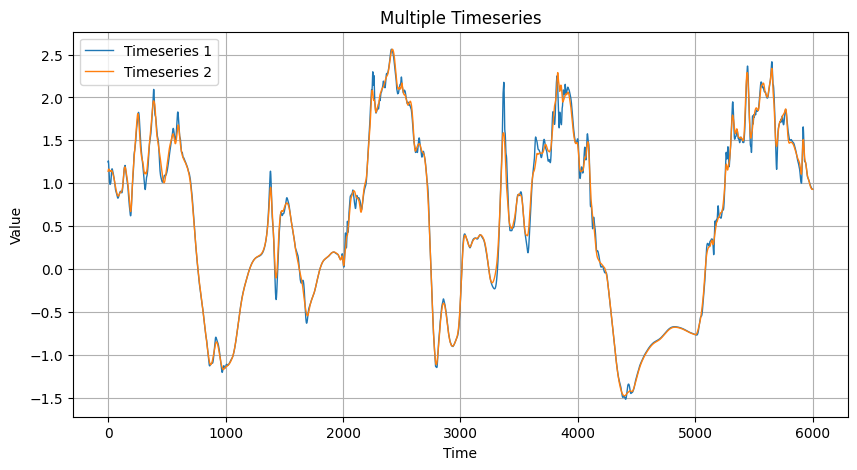

In [21]:
v_x_pdm_test = pdm_approximated_velocity(
    former_point=phi_y_1_test,
    latter_point=phi_y_2_test,
    delta_l=delta_y,
    B=B_z,
    )
v_x_pdm_test = ss_y_true.transform(
    v_x_pdm_test,
    copy=False,
    )
y_pred_lr_pdm_test = model.predict(v_x_pdm_test)
mse_lr_pdm = mean_squared_error(y_true_test, y_pred_lr_pdm_test)
mses['LR-PDM'] = mse_lr_pdm
print(f"mse(LR-PDM) = {mse_lr_pdm}")
plot_timeseries(
    data_list=[
        y_true_test,
        y_pred_c_pdm_test,
        ],
    )

### Comparison

In [22]:
mses

{'General Benchmark': 2.6041296004088333e-05,
 'PDM Benchmark': 0.00420579468061199,
 'PDM': 0.005341697718075174,
 'c-PDM': 0.005186293388467599,
 'LR-PDM': 0.005208824754777562}